# Coil-number experiment: sampling rate versus number of coils

This script evaluates the proposed lifted l1,2 reconstruction method on a
simulated phantom while varying the sampling rate and the number of receive
coils.

This notebook reproduces the experiment shown in Fig. 1 of the paper.

**Note on solvers:**

This experiment uses a direct CVX/CVXPY-based convex optimization solver
to solve the lifted l1,2 minimization problem. The specific backend solver
is determined by the CVX/CVXPY problem setup; see the solver call in this
script for details.

The custom iterative solver is not used in this experiment. It is used for
larger-scale image reconstruction problems where direct convex solvers are
computationally impractical. For example, see:
    lsense.m
    exp/Exp3_realdata_phantom.m
    exp/Exp3_realdata.m
    exp/Exp3_realdata_knee.m


In [1]:
import numpy as np
from scipy.sparse import csc_matrix
from scipy.fftpack import dct
import scipy
import pywt
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp
#from sklearn.datasets import make_sparse_coded_signal
from sklearn.linear_model import OrthogonalMatchingPursuit, OrthogonalMatchingPursuitCV,Lasso


In [ ]:
#JOMP solver
def solver(N,n,Sens,Phi,nl=0,method = 'l1',Phi_inv = None):
    n_c = -1
    for C in [1,2,4,6,8,12,16,24,36]:
        n_c += 1 #loop through different number of coils
        #get sensitivity
        S = Sens[f'c{C}']
        if C==1:
            S = S[np.newaxis,:]
            
        for L in range(1,100): #loop through different number of measurements
            average_error = 0
            for exp in range(n_exp) :
                pattern = np.random.choice(N, L,replace=False)
                pattern[0] = 0 #0-freq
                A = np.asarray([FFT2[i,:] for i in pattern ])
                #Construct the n sparse z_0
                row = np.random.choice(N2, n,replace = False) #choose n rows without replacement from [0,N)
                column = np.repeat([0],n)
                data =  np.random.randn(n)
                z_0 = csc_matrix((data, (row,column)), shape=(N2, 1)).toarray()

                #Construct the forward matrix
                if Phi_inv is None:
                    Phi_inv = Phi.conj().T
                
                D = []
                for i in range(C):
                    Di = A @ np.diag(S[i,:]) @ Phi_inv
                    D.append(Di)
                D = np.vstack(D)
                D = np.concatenate([np.real(D),np.imag(D)],axis = 0)
                #y_0 = D @ z_0 + 0.1 * np.random.randn(D.shape[0],1)#get the measurement
                y_0 = D @ z_0 #get the measurement
                
                #calculate noise
                noise = np.random.randn(*y_0.shape)
                weight = nl * np.linalg.norm(y_0)/np.linalg.norm(noise)
                noise *= weight
                y_0 = y_0 + noise
                
                if method == 'OMP':
                    #Solving the JOMP optimization problem
                    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n)
                    omp.fit(D, y_0)
                    Z = omp.coef_
  
                elif method == 'l1':
                    Z_cp = cp.Variable((N2,1))
                    objective = cp.Minimize(cp.norm(Z_cp,1))
                    constraint = [cp.norm(D@Z_cp-y_0) <= cp.norm(noise)]
                    prob = cp.Problem(objective, constraint)

                    prob.solve()
                    Z= Z_cp.value
                elif method == 'lasso':
                    model = Lasso(alpha=0.01*C)
                    model.fit(D,y_0)
                    Z = model.coef_

                error = np.linalg.norm((Phi_inv @ Z).flatten() - (Phi_inv @ z_0).flatten())/np.linalg.norm((Phi_inv @ z_0).flatten())
                average_error += error 
            
            average_error /= n_exp
            error_out[n_c,L-1] = average_error
    return error_out

In [3]:
N = 529 #true dimention
n_x = 23 #23**2 = 529

In [6]:
n_exp = 100
n = 32 #nonzero entries
error_all = np.zeros((7,100))
Sens = scipy.io.loadmat('../data/Boit_Coil.mat',simplify_cells=True)['S']
Phi = np.kron(dct(np.eye(23),norm='ortho'),dct(np.eye(23),norm='ortho')); N2 = N
FFT2 = np.kron(np.fft.fft(np.eye(23)),np.fft.fft(np.eye(23))) #23**2 = 529

### Sparse recovery baseline

Most curves in this experiment use Orthogonal Matching Pursuit (OMP) as the sparse recovery baseline. In the most challenging/highest-undersampling configuration, OMP was numerically unstable, so the first row of the error matrix is replaced by the corresponding \(\ell_1\)-minimization result. The remaining rows use OMP.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Run OMP baseline for most configurations.
# OMP can be numerically unstable for the first/highest-undersampling case,
# so we replace that row with the l1-minimization result below.
error_all_OMP = solver(N, n, Sens, Phi, 0, 'OMP')

# Use l1 minimization for the first configuration where OMP is unstable.
error_first_l1 = solver(N, n, Sens, Phi, 0, 'l1')

# Replace the first row of the OMP result matrix with the l1 result.
# The remaining rows are still from OMP.
error_all_OMP[0, :] = error_first_l1

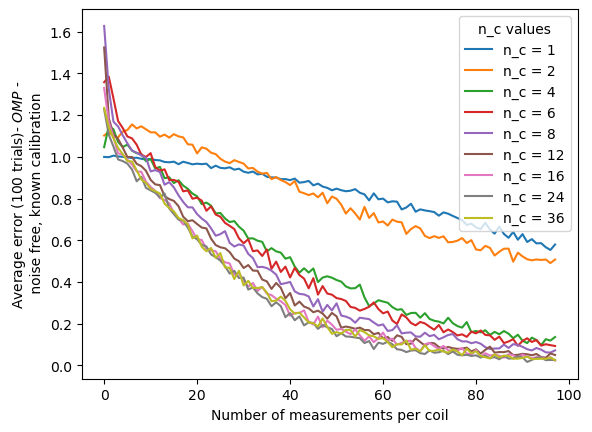

In [ ]:
n_c = [1,2,4,6,8,12,16,24,36]

for i in range(error_all_OMP.shape[0]):
    plt.plot((error_all_OMP[i,1:-1]), label=f'n_c = {n_c[i]}')  # Plot each row with a label

# Add title and labels
plt.xlabel("Number of measurements per coil") 
plt.ylabel("Average error (100 trials)- $OMP$ - \n noise free, known calibration")  

# Add the legend
plt.legend(title="n_c values", loc='best')

# Show the plot
plt.savefig('Ot1.png', dpi=300)  # You can specify other formats like .pdf, .jpg, etc.
plt.show()


Noisy sparse-recovery baseline

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Noisy case: sigma = 0.1
# Run OMP baseline for most configurations.
# OMP is numerically unstable for the first/highest-undersampling row,
# so we replace that row with the corresponding l1-minimization result.
noise_level = 0.1

error_all_baseline_ns = solver(N, n, Sens, Phi, noise_level, 'OMP')

# Replace the first row with l1 minimization for stability.
error_first_l1_ns = solver(N, n, Sens, Phi, noise_level, 'l1')
error_all_baseline_ns[0, :] = error_first_l1_ns

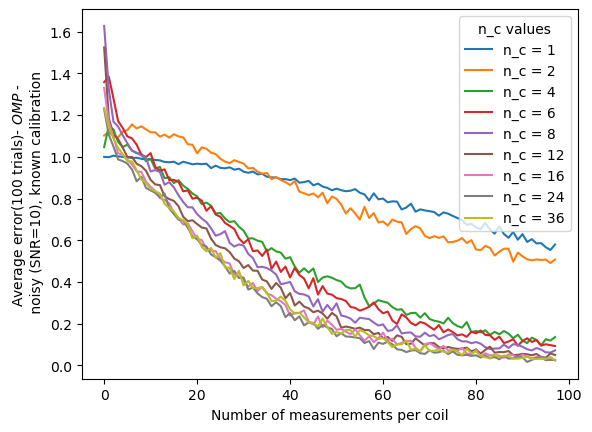

In [ ]:
n_c = [1,2,4,6,8,12,16,24,36]
for i in range(error_all_baseline_ns.shape[0]):
    plt.plot((error_all_baseline_ns[i,1:-1]), label=f'n_c = {n_c[i]}')  # Plot each row with a label

# Add title and labels
#plt.title("Success Experiments")
plt.xlabel("Number of measurements per coil") 
plt.ylabel("Average error(100 trials)- $OMP$ - \n noisy (SNR=10), known calibration")  

# Add the legend
plt.legend(title="n_c values", loc='best')

# Show the plot
plt.savefig('Ot2.png', dpi=300)  # You can specify other formats like .pdf, .jpg, etc
plt.show()